<a href="https://colab.research.google.com/github/sjsu-cs131-spring26/trendtrackers-engagement-socialmedia/blob/main/finaldemo_trendtrackers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1: Setup Project Variables**

In [15]:
PROJECT_ID = "trendtrackers-final-cs131"
REGION = "us-central1"
BUCKET = "fulldata-trendtrackers"

DATA_PATH = f"gs://{BUCKET}/processed_data_*.parquet"
OUTPUT_PATH = f"gs://{BUCKET}/output/final_sprint/"
CODE_PATH = f"gs://{BUCKET}/code/final_pipeline.py"

!gsutil ls gs://{BUCKET}/processed_data_*.parquet | head

gs://fulldata-trendtrackers/processed_data_0.parquet
gs://fulldata-trendtrackers/processed_data_1.parquet
gs://fulldata-trendtrackers/processed_data_10.parquet
gs://fulldata-trendtrackers/processed_data_100.parquet
gs://fulldata-trendtrackers/processed_data_101.parquet
gs://fulldata-trendtrackers/processed_data_102.parquet
gs://fulldata-trendtrackers/processed_data_103.parquet
gs://fulldata-trendtrackers/processed_data_104.parquet
gs://fulldata-trendtrackers/processed_data_105.parquet
gs://fulldata-trendtrackers/processed_data_106.parquet
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


# **2: Setup GCP**

In [16]:
from google.colab import auth
auth.authenticate_user()

!gcloud config set project {PROJECT_ID}

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].


# **3: PySpark Pipeline**

In [29]:
pipeline_code = """
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg, regexp_extract, row_number, to_date
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("CS131_Final_Project").getOrCreate()

input_path = "DATA_PATH_PLACEHOLDER"
output_path = "OUTPUT_PATH_PLACEHOLDER"

df = spark.read.parquet(input_path)

print("Schema:")
df.printSchema()

print("Row count:", df.count())

# basic cleaning
clean_df = (
    df
    .filter(col("original_text").isNotNull())
    .filter(col("language").isNotNull())
    .filter(col("primary_theme").isNotNull())
)

# table 1: posts by language
language_counts = (
    clean_df.groupBy("language")
    .agg(count("*").alias("post_count"))
    .orderBy(col("post_count").desc())
)

language_counts.write.mode("overwrite").parquet(output_path + "language_counts")

# table 2: posts by theme
theme_counts = (
    clean_df.groupBy("primary_theme")
    .agg(count("*").alias("post_count"))
    .orderBy(col("post_count").desc())
)

theme_counts.write.mode("overwrite").parquet(output_path + "theme_counts")

# table 3: sentiment by theme
sentiment_by_theme = (
    clean_df.groupBy("primary_theme")
    .agg(
        count("*").alias("post_count"),
        avg("sentiment").alias("avg_sentiment")
    )
    .orderBy(col("post_count").desc())
)

sentiment_by_theme.write.mode("overwrite").parquet(output_path + "sentiment_by_theme")

# table 4: top domains
domain_df = clean_df.withColumn(
    "domain",
    regexp_extract(col("url"), "https?://([^/]+)", 1)
)

top_domains = (
    domain_df
    .filter(col("domain") != "")
    .groupBy("domain")
    .agg(count("*").alias("post_count"))
    .orderBy(col("post_count").desc())
)

top_domains.write.mode("overwrite").parquet(output_path + "top_domains")

# table 5: top themes per language using window function
lang_theme = (
    clean_df
    .groupBy("language", "primary_theme")
    .agg(count("*").alias("post_count"))
)

window = Window.partitionBy("language").orderBy(col("post_count").desc())

top_themes = (
    lang_theme
    .withColumn("rank", row_number().over(window))
    .filter(col("rank") <= 3)
    .orderBy("language", "rank")
)

top_themes.write.mode("overwrite").parquet(output_path + "top_themes_per_language")

# table 6: daily activity over time
daily_activity = (
    clean_df
    .withColumn("post_date", to_date(col("date")))
    .filter(col("post_date").isNotNull())
    .groupBy("post_date")
    .agg(count("*").alias("post_count"))
    .orderBy("post_date")
)

daily_activity.write.mode("overwrite").parquet(output_path + "daily_activity")

spark.stop()
"""

pipeline_code = pipeline_code.replace("DATA_PATH_PLACEHOLDER", DATA_PATH)
pipeline_code = pipeline_code.replace("OUTPUT_PATH_PLACEHOLDER", OUTPUT_PATH)

with open("final_pipeline.py", "w") as f:
    f.write(pipeline_code)

print("Updated final_pipeline.py.")

Updated final_pipeline.py.


# **4: Pipeline to GCP**

In [31]:
!gsutil cp final_pipeline.py {CODE_PATH}
!gsutil ls gs://{BUCKET}/code/

!gcloud dataproc batches submit pyspark {CODE_PATH} \
  --region={REGION} \
  --deps-bucket=gs://{BUCKET}

## Checkout outputs
!gsutil ls -r {OUTPUT_PATH}

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://final_pipeline.py [Content-Type=text/x-python]...
/ [1 files][  2.6 KiB/  2.6 KiB]                                                
Operation completed over 1 objects/2.6 KiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://fulldata-trendtrackers/code/final_pipeline.py
Batch [c7cda5b08c84452ea96fc589b971778c] submitted.
Using the default container image
Waiting for container log creation
PYSPARK_PYTHON=/opt/dataproc/conda/bin/python
Generating /home/spark/.pip/pip.conf

# **5: Visualizations**

In [32]:
!pip install gcsfs pyarrow

In [34]:
import pandas as pd

language_counts = pd.read_parquet(f"{OUTPUT_PATH}language_counts")
theme_counts = pd.read_parquet(f"{OUTPUT_PATH}theme_counts")
sentiment = pd.read_parquet(f"{OUTPUT_PATH}sentiment_by_theme")
domains = pd.read_parquet(f"{OUTPUT_PATH}top_domains")
daily_activity = pd.read_parquet(f"{OUTPUT_PATH}daily_activity")

## **Top Languages**

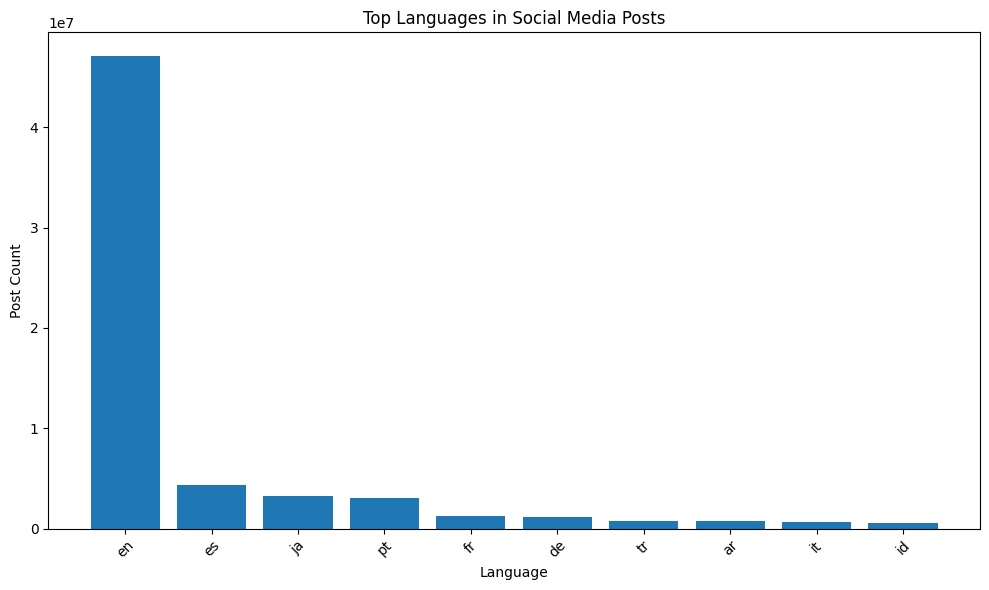

In [35]:
import matplotlib.pyplot as plt

top_lang = language_counts.head(10)

plt.figure(figsize=(10,6))
plt.bar(top_lang["language"], top_lang["post_count"])
plt.title("Top Languages in Social Media Posts")
plt.xlabel("Language")
plt.ylabel("Post Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Common Themes**

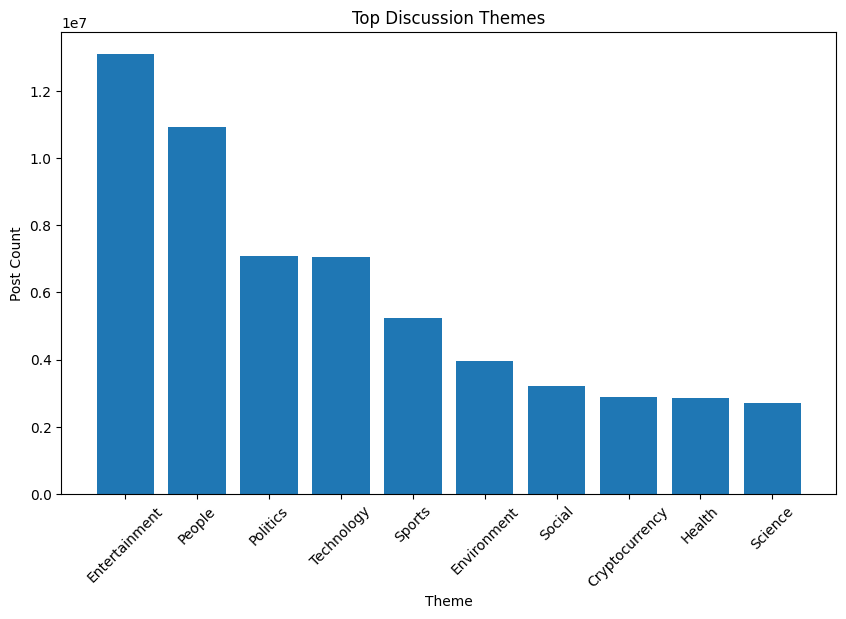

In [36]:
top_themes = theme_counts.head(10)

plt.figure(figsize=(10,6))
plt.bar(top_themes["primary_theme"], top_themes["post_count"])
plt.title("Top Discussion Themes")
plt.xlabel("Theme")
plt.ylabel("Post Count")
plt.xticks(rotation=45)
plt.show()

## **Sentiment by Theme**

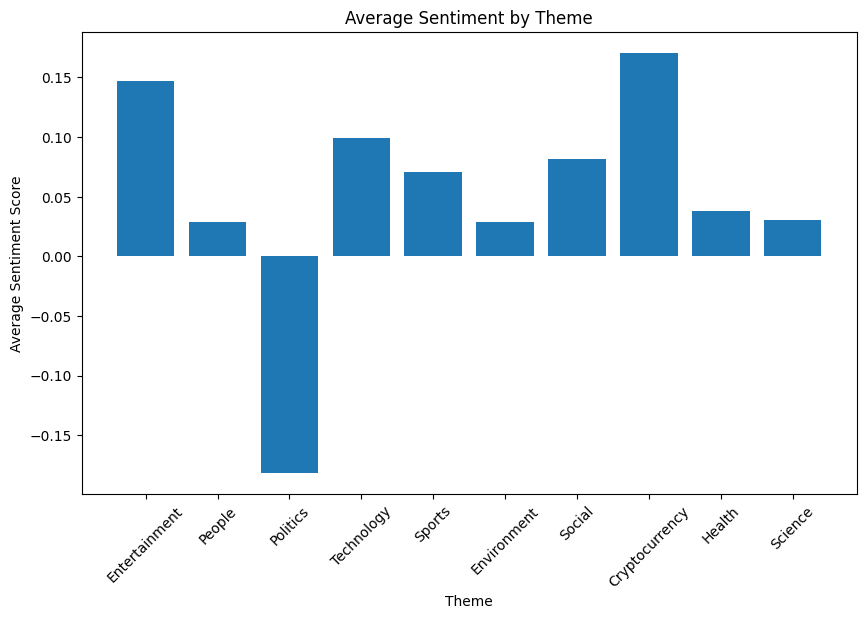

In [37]:
sentiment_plot = sentiment.head(10)

plt.figure(figsize=(10,6))
plt.bar(sentiment_plot["primary_theme"], sentiment_plot["avg_sentiment"])
plt.title("Average Sentiment by Theme")
plt.xlabel("Theme")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=45)
plt.show()

## **Theme vs. Sentiment**

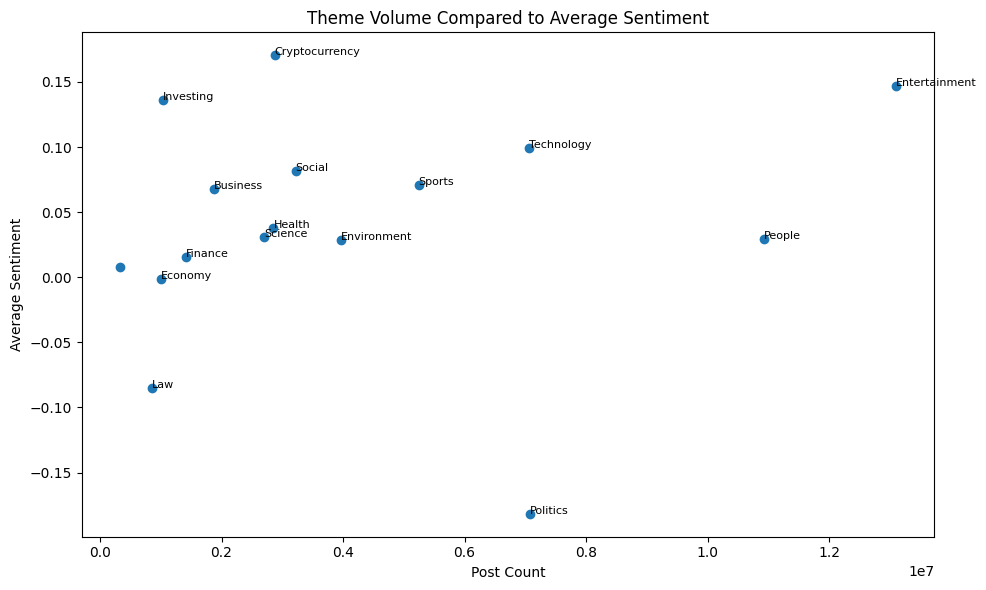

In [38]:
sentiment_scatter = sentiment.sort_values("post_count", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.scatter(
    sentiment_scatter["post_count"],
    sentiment_scatter["avg_sentiment"]
)

for index, row in sentiment_scatter.iterrows():
    plt.text(
        row["post_count"],
        row["avg_sentiment"],
        row["primary_theme"],
        fontsize=8
    )

plt.title("Theme Volume Compared to Average Sentiment")
plt.xlabel("Post Count")
plt.ylabel("Average Sentiment")
plt.tight_layout()
plt.show()

## **Daily Posting**

In [39]:
daily_activity = pd.read_parquet(
    f"{OUTPUT_PATH}daily_activity"
)

daily_activity = daily_activity.sort_values("post_date")

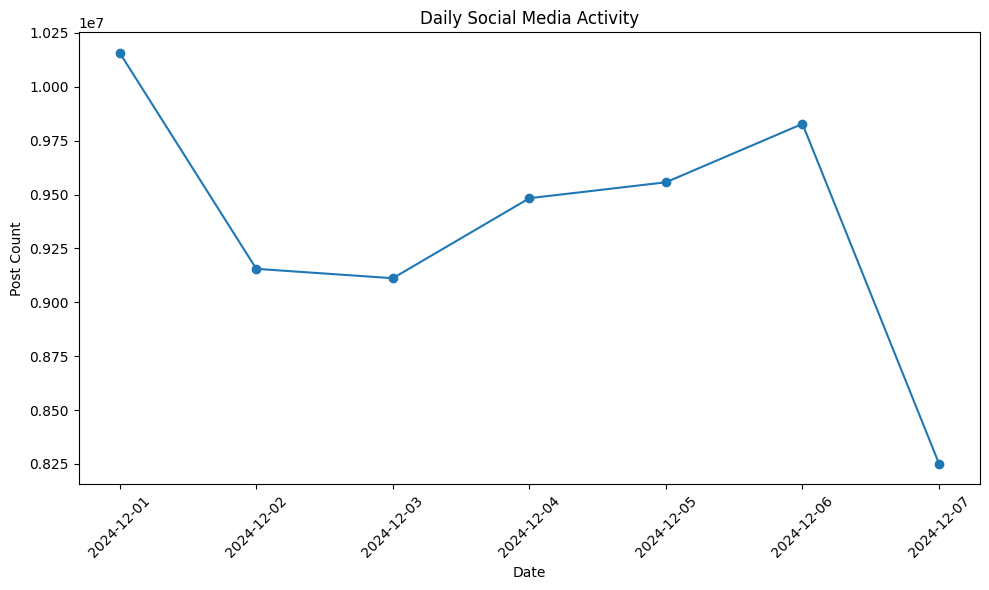

In [40]:
plt.figure(figsize=(10,6))
plt.plot(daily_activity["post_date"], daily_activity["post_count"], marker="o")
plt.title("Daily Social Media Activity")
plt.xlabel("Date")
plt.ylabel("Post Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Showcasing Tables**
Reading Spark Output Tables (.parquet files from Cloud Storage)

In [42]:
OUTPUT_PATH = "gs://fulldata-trendtrackers/output/final_sprint/"

In [43]:
import pandas as pd

language_counts = pd.read_parquet(OUTPUT_PATH + "language_counts")
theme_counts = pd.read_parquet(OUTPUT_PATH + "theme_counts")
sentiment_by_theme = pd.read_parquet(OUTPUT_PATH + "sentiment_by_theme")
top_domains = pd.read_parquet(OUTPUT_PATH + "top_domains")
top_themes_per_language = pd.read_parquet(OUTPUT_PATH + "top_themes_per_language")
daily_activity = pd.read_parquet(OUTPUT_PATH + "daily_activity")

print("Parquet tables loaded from Cloud Storage")

Parquet tables loaded from Cloud Storage


In [44]:
print("language_counts columns:", language_counts.columns)
print("theme_counts columns:", theme_counts.columns)
print("sentiment_by_theme columns:", sentiment_by_theme.columns)
print("top_domains columns:", top_domains.columns)
print("top_themes_per_language columns:", top_themes_per_language.columns)
print("daily_activity columns:", daily_activity.columns)

language_counts columns: Index(['language', 'post_count'], dtype='object')
theme_counts columns: Index(['primary_theme', 'post_count'], dtype='object')
sentiment_by_theme columns: Index(['primary_theme', 'post_count', 'avg_sentiment'], dtype='object')
top_domains columns: Index(['domain', 'post_count'], dtype='object')
top_themes_per_language columns: Index(['language', 'primary_theme', 'post_count', 'rank'], dtype='object')
daily_activity columns: Index(['post_date', 'post_count'], dtype='object')


In [48]:
print("Language Counts")
display(language_counts.head(25))

Language Counts


,language,post_count
0,en,47123102
1,es,4370574
2,ja,3215049
3,pt,3089805
4,fr,1291914
5,de,1124985
6,tr,742920
7,ar,732799
8,it,626293
9,id,588700


In [49]:
print("Theme Counts")
display(theme_counts.head(25))



Theme Counts


,primary_theme,post_count
0,Entertainment,13096061
1,People,10923983
2,Politics,7080113
3,Technology,7062616
4,Sports,5243188
5,Environment,3963989
6,Social,3219680
7,Cryptocurrency,2874674
8,Health,2854992
9,Science,2701759


In [50]:
print("Sentiment by Theme")
display(sentiment_by_theme.head(25))


Sentiment by Theme


,primary_theme,post_count,avg_sentiment
0,Entertainment,13096061,0.147177
1,People,10923983,0.029126
2,Politics,7080113,-0.181695
3,Technology,7062616,0.099314
4,Sports,5243188,0.071088
5,Environment,3963989,0.028529
6,Social,3219680,0.081555
7,Cryptocurrency,2874674,0.170475
8,Health,2854992,0.037819
9,Science,2701759,0.030682


In [51]:
print("Top Domains")
display(top_domains.head(25))


Top Domains


,domain,post_count
0,x.com,43653592
1,www.reddit.com,9604630
2,bsky.app,6219355
3,reddit.com,3046885
4,www.youtube.com,1560470
5,boards.4channel.org,205888
6,www.jeuxvideo.com,52718
7,forocoches.com,48287
8,news.ycombinator.com,28278
9,news.yahoo.co.jp,11184


In [52]:
print("Top Themes per Language")
display(top_themes_per_language.head(25))



Top Themes per Language


,language,primary_theme,post_count,rank
0,af,Entertainment,489,1
1,af,Environment,205,2
2,af,People,185,3
3,am,Entertainment,435,1
4,am,Politics,193,2
5,am,Law,114,3
6,an,Entertainment,547,1
7,an,People,118,2
8,an,Environment,47,3
9,ar,Sports,217749,1


In [53]:
print("Daily Activity")
display(daily_activity.head(25))

Daily Activity


,post_date,post_count
0,2024-12-01,10157144
1,2024-12-02,9155134
2,2024-12-03,9111601
3,2024-12-04,9482851
4,2024-12-05,9556752
5,2024-12-06,9827793
6,2024-12-07,8250936
